# Hu Moments

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

## Corner extraction

In [2]:
BASE_DIR = Path.cwd()

CARDS_DIR = BASE_DIR / "cards"

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff",
}

In [3]:
# Fraction of card size used for the corner crop
CORNER_WIDTH_RATIO = 0.33
CORNER_HEIGHT_RATIO = 0.17

In [6]:
def load_card_images(cards_dir: Path):

    paths = sorted(
        path for path in cards_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    )

    images = []

    for path in paths:

        image_bgr = cv2.imread(str(path))

        if image_bgr is None:
            print(f"Skipping unreadable image: {path}")
            continue

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        images.append((path.name, image_rgb))

    return images


def extract_top_left_corner(card_rgb: np.ndarray):

    height, width = card_rgb.shape[:2]

    corner_w = int(width * CORNER_WIDTH_RATIO)
    corner_h = int(height * CORNER_HEIGHT_RATIO)

    corner = card_rgb[
        0:corner_h,
        0:corner_w
    ]

    return corner


def extract_bottom_right_corner(card_rgb: np.ndarray):

    height, width = card_rgb.shape[:2]

    corner_w = int(width * CORNER_WIDTH_RATIO)
    corner_h = int(height * CORNER_HEIGHT_RATIO)

    corner = card_rgb[
        height - corner_h:height,
        width - corner_w:width
    ]

    # rotate 180 degrees so symbols are upright
    corner = cv2.rotate(corner, cv2.ROTATE_180)

    return corner


def show_corner_extraction(cards):

    preview_cards = cards[13:26]

    rows = len(preview_cards)

    fig, axes = plt.subplots(
        rows,
        3,
        figsize=(12, 4 * rows)
    )

    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_axes, (name, card_rgb) in zip(axes, preview_cards):

        top_left = extract_top_left_corner(card_rgb)

        bottom_right = extract_bottom_right_corner(card_rgb)

        row_axes[0].imshow(card_rgb)
        row_axes[0].set_title(name)
        row_axes[0].axis("off")

        row_axes[1].imshow(top_left)
        row_axes[1].set_title("Top-left ROI")
        row_axes[1].axis("off")

        row_axes[2].imshow(bottom_right)
        row_axes[2].set_title("Bottom-right ROI")
        row_axes[2].axis("off")

    plt.tight_layout()
    plt.show()

Loaded 54 cards


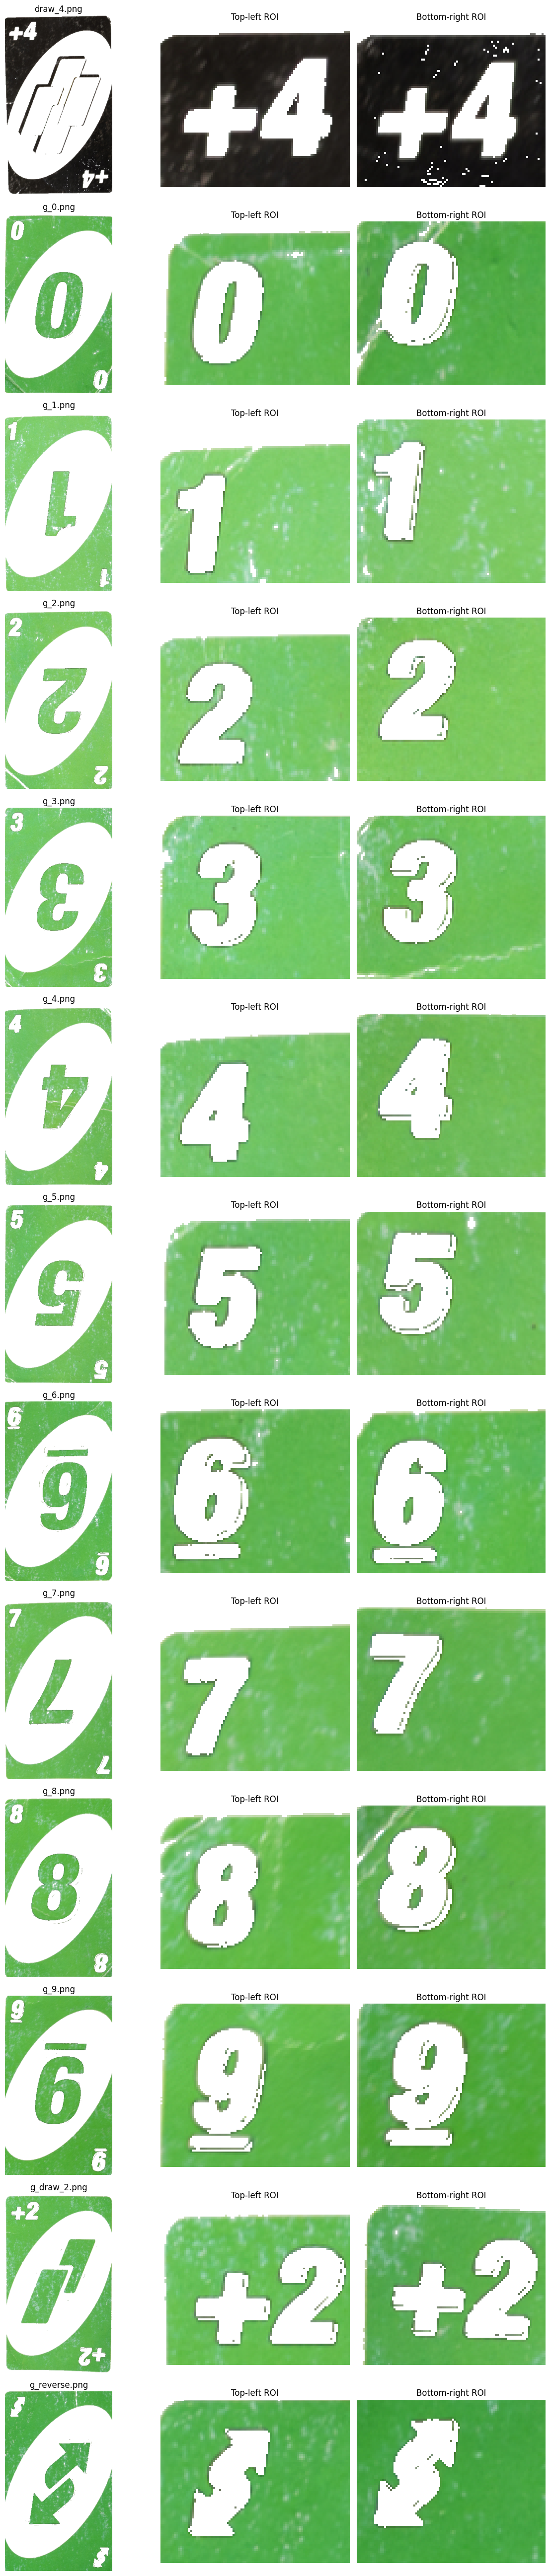

In [7]:
cards = load_card_images(CARDS_DIR)

print(f"Loaded {len(cards)} cards")

show_corner_extraction(cards)

## Threshold + Morphology

In [8]:
def show(img, title="Image", cmap="gray"):
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [9]:
def dynamic_corner_crop(roi, threshold=200, step=1):
    """
    Dynamically crops top-left border by scanning inward until
    pixel intensity stops matching border/background.

    Args
    ----
    roi : np.ndarray
        Corner image
    threshold : int
        Brightness threshold for "border-like" pixels
    step : int
        scanning step size

    Returns
    -------
    cropped : np.ndarray
    """

    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape

    # ---- find top boundary ----
    top = 0
    for i in range(h):
        row_mean = np.mean(gray[i, :])
        if row_mean < threshold:  # entered "content"
            top = i
            break

    # ---- find left boundary ----
    left = 0
    for j in range(w):
        col_mean = np.mean(gray[:, j])
        if col_mean < threshold:
            left = j
            break

    # keep full bottom/right (safe)
    cropped = roi[top:, left:]

    # remove remaining top-left artifact
    h, w = cropped.shape[:2]
    cropped = cropped[int(0.1*h):, int(0.1*w):]

    return cropped

In [10]:
def preprocess_symbol(roi):
    """
    Preprocess UNO corner ROI for contour extraction.

    Args
    ----
    roi : np.ndarray
        Corner ROI image

    Returns
    -------
    cleaned : np.ndarray
        Binary cleaned image
    """

    # Convert to grayscale
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    # Blur to reduce noise
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Threshold
    # White symbol becomes white, background black
    _, thresh = cv2.threshold(
        blur,
        220,                # adjust manually
        255,
        cv2.THRESH_BINARY
    )

    # Morphological kernels
    kernel = np.ones((3,3), np.uint8)

    # Opening = remove tiny noise
    opened = cv2.morphologyEx(
        thresh,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )
    
    #Closing = fill small holes
    cleaned = cv2.morphologyEx(
        opened,
       cv2.MORPH_CLOSE,
       kernel,
       iterations=1
    )

    return cleaned

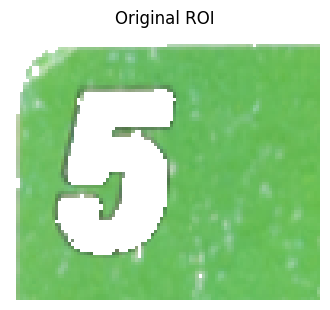

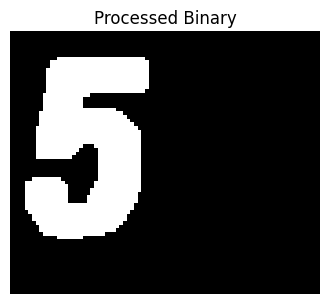

In [45]:
# Test preprocessing on one card corner

# Take first loaded card
card_name, card_rgb = cards[19]

# Extract one corner ROI
roi = extract_top_left_corner(card_rgb)

cropped = dynamic_corner_crop(roi, threshold=200, step=1)

# Preprocess
processed = preprocess_symbol(cropped)

# Display
show(roi, "Original ROI", cmap=None)
show(processed, "Processed Binary")

## Hu Moments

In [97]:
def compute_hu_moments(binary_img):
    """
    Compute Hu invariant moments from a binary image.

    Args
    ----
    binary_img : np.ndarray
        Binary symbol image

    Returns
    -------
    hu : np.ndarray (7,)
        7 Hu invariant moments
    """

    # Compute regular image moments
    moments = cv2.moments(binary_img)

    # Compute Hu moments
    hu = cv2.HuMoments(moments)

    # Flatten to 1D vector
    hu = hu.flatten()

    # Log transform for numerical stability
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    return hu

In [98]:
hu = compute_hu_moments(processed)

print("Hu moments:")
print(hu)

Hu moments:
[  3.11975801   6.72957069   9.99993272   9.99999597 -10.
 -10.          10.        ]


# Compute descriptors for green cards

In [99]:
# ============================================================
# TRAINING SET
# ============================================================

train_indices = list(range(13, 27)) + [40]

train_descriptors = []
train_labels = []

for idx in train_indices:

    card_name, card_rgb = cards[idx]

    # preprocessing pipeline
    roi = extract_top_left_corner(card_rgb)

    cropped = dynamic_corner_crop(roi)

    processed = preprocess_symbol(cropped)

    # descriptor
    hu = compute_hu_moments(processed)

    train_descriptors.append(hu)

    # symbol only
    label = extract_symbol_label(card_name)

    train_labels.append(label)

train_descriptors = np.array(train_descriptors)

print("Training descriptors:", train_descriptors.shape)

Training descriptors: (15, 7)


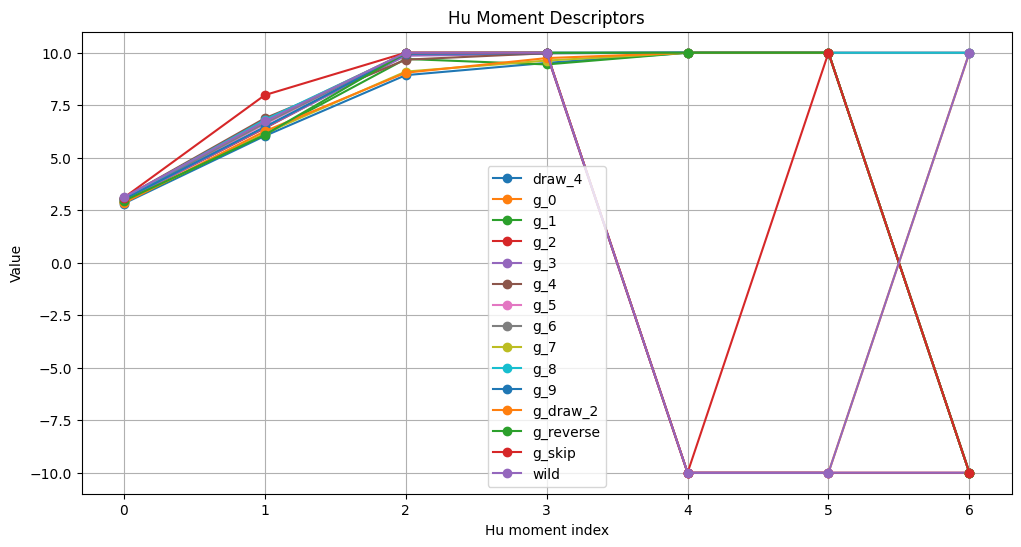

In [100]:
plt.figure(figsize=(12,6))

for i in range(len(labels)):

    plt.plot(
        descriptors[i],
        marker='o',
        label=labels[i]
    )

plt.xlabel("Hu moment index")
plt.ylabel("Value")
plt.title("Hu Moment Descriptors")
plt.legend()
plt.grid()
plt.show()

In [101]:
def extract_symbol_label(filename):
    """
    Extract only the UNO symbol from filename.

    Examples
    --------
    green_5.png  -> 5
    blue_skip.png -> skip
    red_plus2.png -> plus2
    """

    name = Path(filename).stem

    # split at first underscore
    parts = name.split("_", 1)

    if len(parts) < 2:
        return name

    return parts[1]

In [102]:
# ============================================================
# TEST SET
# ============================================================

test_indices = (
    list(range(0, 13)) +
    list(range(28, 40)) +
    list(range(41, 54))
)

In [103]:
# ============================================================
# TEST RECOGNITION
# ============================================================

correct = 0
total = 0

for idx in test_indices:

    card_name, card_rgb = cards[idx]

    # preprocessing pipeline
    roi = extract_top_left_corner(card_rgb)

    cropped = dynamic_corner_crop(roi)

    processed = preprocess_symbol(cropped)

    # compute descriptor
    test_descriptor = compute_hu_moments(processed)

    # ----------------------------------------
    # Compare against all training descriptors
    # ----------------------------------------

    distances = np.linalg.norm(
        train_descriptors - test_descriptor,
        axis=1
    )

    best_match_idx = np.argmin(distances)

    predicted_label = train_labels[best_match_idx]

    true_label = extract_symbol_label(card_name)

    # ----------------------------------------
    # Result
    # ----------------------------------------

    is_correct = predicted_label == true_label

    if is_correct:
        correct += 1

    total += 1

    print(
        f"{card_name:25s} | "
        f"Predicted: {predicted_label:10s} | "
        f"True: {true_label:10s} | "
        f"{'OK' if is_correct else 'WRONG'}"
    )

# ============================================================
# FINAL ACCURACY
# ============================================================

accuracy = correct / total * 100

print("\n========================")
print(f"Accuracy: {accuracy:.2f}%")
print("========================")

b_0.png                   | Predicted: 8          | True: 0          | WRONG
b_1.png                   | Predicted: 4          | True: 1          | WRONG
b_2.png                   | Predicted: 9          | True: 2          | WRONG
b_3.png                   | Predicted: 3          | True: 3          | OK
b_4.png                   | Predicted: 4          | True: 4          | OK
b_5.png                   | Predicted: 8          | True: 5          | WRONG
b_6.png                   | Predicted: 6          | True: 6          | OK
b_7.png                   | Predicted: 7          | True: 7          | OK
b_8.png                   | Predicted: 4          | True: 8          | WRONG
b_9.png                   | Predicted: 9          | True: 9          | OK
b_draw_2.png              | Predicted: draw_2     | True: draw_2     | OK
b_reverse.png             | Predicted: reverse    | True: reverse    | OK
b_skip.png                | Predicted: 3          | True: skip       | WRONG
r_1.png             